**IMPORTING LIBRARIES**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('/content/OnlineRetail.csv', encoding='latin1')

**BASIC EXPLORATION**

In [ ]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2.0,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6.0,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6.0,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6.0,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32.0,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162913 entries, 0 to 162912
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    162913 non-null  object 
 1   StockCode    162913 non-null  object 
 2   Description  162283 non-null  object 
 3   Quantity     162912 non-null  float64
 4   InvoiceDate  162912 non-null  object 
 5   UnitPrice    162912 non-null  float64
 6   CustomerID   113420 non-null  float64
 7   Country      162912 non-null  object 
dtypes: float64(3), object(5)
memory usage: 9.9+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,162912.000000,162912.000000,113420.000000
mean,9.051463,5.060244,15289.260377
std,265.828567,98.747789,1732.848052
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13842.000000
50%,3.000000,2.460000,15194.000000
75%,10.000000,4.210000,16858.000000
max,74215.000000,16888.020000,18283.000000


In [ ]:
df.describe(include = 'object')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,162913,162913,162283,162912,162912
unique,8072,3344,3257,7293,34
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,12/6/2010 16:57,United Kingdom
freq,675,890,900,675,150390


**REMOVING NULL AND DUPLICATES**

In [ ]:
df.isna()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
162908,False,False,False,False,False,False,False,False
162909,False,False,False,False,False,False,False,False
162910,False,False,False,False,False,False,False,False
162911,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,630
Quantity,1
InvoiceDate,1
UnitPrice,1
CustomerID,49493
Country,1


In [ ]:
df.dropna(inplace = True)

In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
df.duplicated().sum()

np.int64(1457)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

**OUTLIER DETECTION USING BOXPLOT**

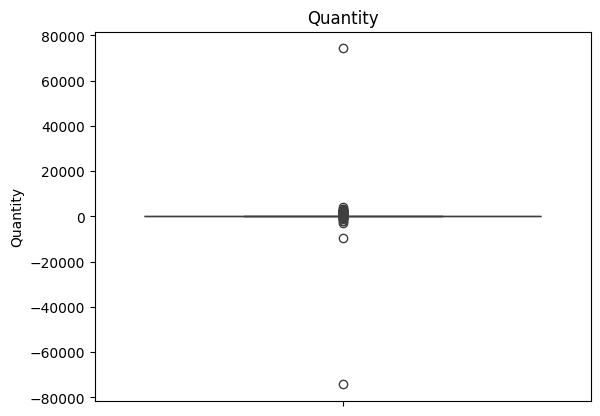

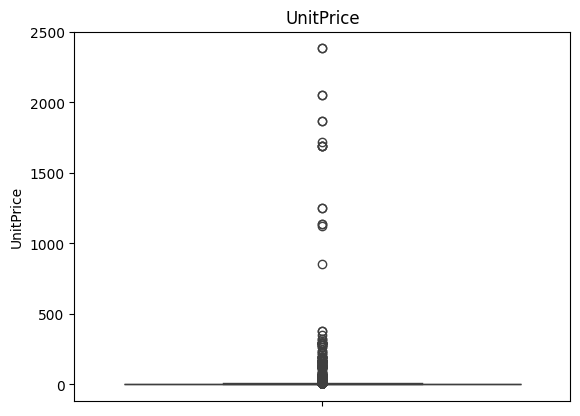

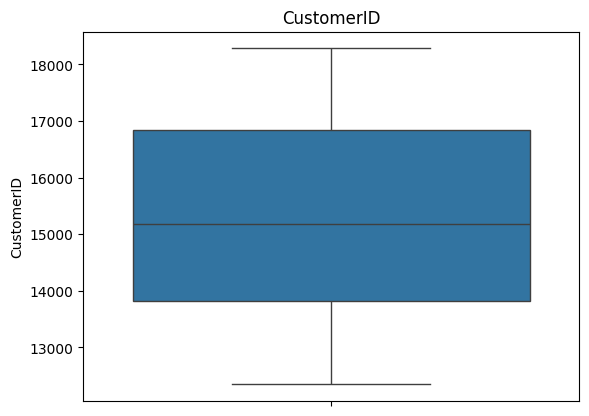

In [ ]:
for i in df.columns:
  if df[i].dtypes != 'object':
    sns.boxplot(df[i])
    plt.title(i)
    plt.show()

**SELECTING NUMERIC COLUMNS FROM DF**

In [ ]:
num = df.select_dtypes(include = 'number')

In [ ]:
num

,Quantity,UnitPrice,CustomerID
0,6.0,2.55,17850.0
1,6.0,3.39,17850.0
2,8.0,2.75,17850.0
3,6.0,3.39,17850.0
4,6.0,3.39,17850.0
...,...,...,...
162907,24.0,0.65,12947.0
162908,24.0,0.65,12947.0
162909,12.0,1.25,12947.0
162910,12.0,1.25,12947.0


**IQR METHOD TO REMOVE OUTLIERS**

In [ ]:
Q3 = num.quantile(0.75)
Q1 = num.quantile(0.25)

IQR = Q3 - Q1 #INTER QUANTILE RANGE IS DIFFERENCE B/W Q3 & Q1

lower_bound = Q1 - 1.5 * IQR #SETTING THE LOWER BOUND AND UPPER BOUND AS A THRESHOLD FOR OUTLIER CLEANING PROCESS
upper_bound = Q3 + 1.5 * IQR

In [ ]:
outlier_clean = df[((df[num.columns] >= lower_bound) & (df[num.columns] <= upper_bound)).all(axis=1)]

In [ ]:
df_cleaned = outlier_clean #HANDLED OUTLIERS FROM THE DATASET

In [ ]:
df_cleaned

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
162907,550522,20975,12 PENCILS SMALL TUBE RED RETROSPOT,24.0,4/19/2011 10:04,0.65,12947.0,United Kingdom
162908,550522,20974,12 PENCILS SMALL TUBE SKULL,24.0,4/19/2011 10:04,0.65,12947.0,United Kingdom
162909,550522,22562,MONSTERS STENCIL CRAFT,12.0,4/19/2011 10:04,1.25,12947.0,United Kingdom
162910,550522,22563,HAPPY STENCIL CRAFT,12.0,4/19/2011 10:04,1.25,12947.0,United Kingdom


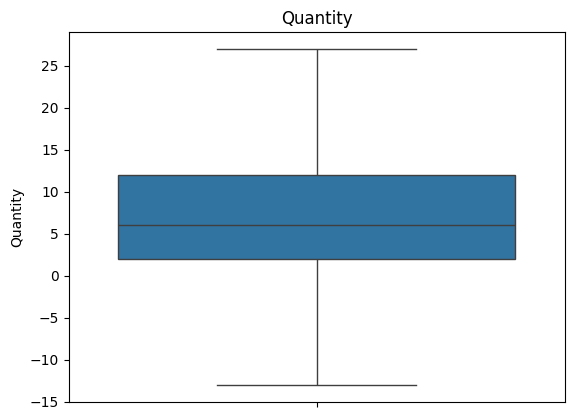

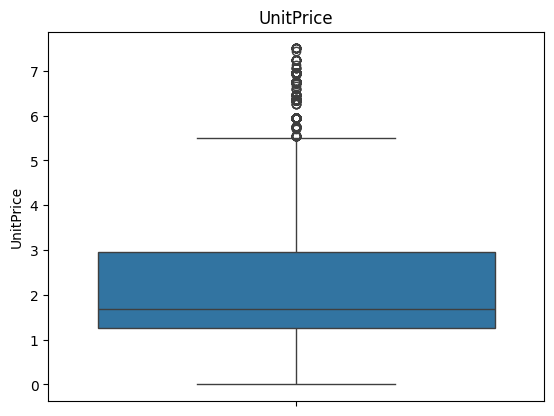

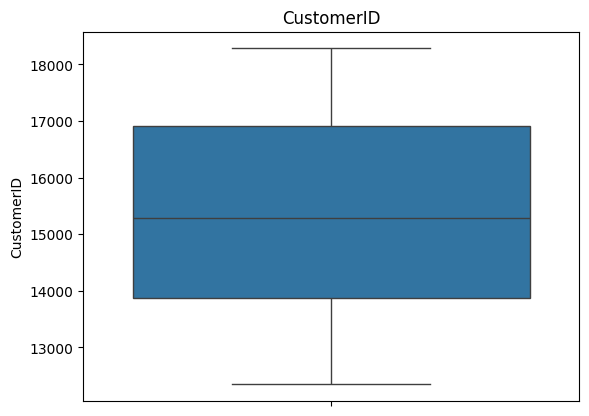

In [ ]:
for i in df_cleaned.columns:
  if df_cleaned[i].dtypes != 'object':
    sns.boxplot(df_cleaned[i])
    plt.title(i)
    plt.show()

In [ ]:
df_clean['InvoiceNo'].value_counts() # CANCELLED ORDERS DONT COUNT IN THE RFM ANALYSIS SO WE DROP THE INVOICE STARTING WITH 'C' OR 'c'

,count
InvoiceNo,
C548460,45
C542426,35
C538341,30
C538350,26
C546997,22
...,...
C536757,1
C536737,1
C536642,1


In [ ]:
df_clean = outlier_clean
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith(('C', 'c'))]

In [ ]:
df_cleaned['InvoiceNo'].value_counts()

,count
InvoiceNo,
547063,260
543040,231
540372,150
545901,144
548714,142
...,...
537052,1
544192,1
C544300,1


**REMOVING UNWANTED FEATURES FOR RFM ANALYSIS**

In [ ]:
df_cleaned = df.drop(columns = ['StockCode','Description'],inplace = True)

In [ ]:
df_cleaned

**IMPORTING CLEANED DATASET WHICH IS READY FOR SQL LOADING**

In [ ]:
df.to_csv('df_cleaned.csv',index = False)